# Self-Supervised pre-training (SimCLR) на своих изображениях с LightlySSL

1. Берем **изображения без разметки** (папка с `.jpg/.png/...`).
2. Делаем **self-supervised предобучение** методом **SimCLR** (contrastive learning) с помощью **LightlySSL**.
3. Применяем предобученный backbone к **downstream задаче**: **поиск похожих изображений (image retrieval)**.

Почему так:
- SimCLR учит сеть выделять устойчивые визуальные признаки без меток (две аугментации одного изображения должны иметь близкие представления).
- Retrieval — очень практичная задача CV и не требует разметки, при этом хорошо демонстрирует пользу предобученных эмбеддингов.

## Что нужно от окружения
- `torch`, `torchvision`
- `lightly`
- `PIL`, `tqdm`, `matplotlib`




In [ ]:
import importlib
import sys
from pathlib import Path

def find_existing_file(candidate_paths: list[Path]) -> Path:
    for p in candidate_paths:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find requirements.txt. Tried: " + ", ".join(map(str, candidate_paths)))

cwd = Path.cwd().resolve()
candidate_rel = [
    Path("requirements.txt"),
    Path("ssl_lightly/requirements.txt"),
    Path("ImageProcessingAndRecognition/ssl_lightly/requirements.txt"),
]
candidates = []
for base in [cwd, *cwd.parents]:
    candidates.extend([base / rel for rel in candidate_rel])

req_path = find_existing_file(candidates)
BASE_DIR = req_path.parent
try:
    importlib.import_module("lightly")
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])


In [12]:
import os
import random
import time
from dataclasses import dataclass
from typing import Iterable

import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
import lightly
print("lightly:", lightly.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


python: 3.13.7
torch: 2.9.1
torchvision: 0.24.1
lightly: 1.5.22
device: cpu


## 1) Данные

Берем изображения из уже имеющегося датасета в репозитории:

- train: `Dataset/images/train`
- val: `Dataset/images/val`

Важно: для self-supervised **разметка не нужна**, достаточно только изображений.

Чтобы тетрадка выполнялась быстро, далее мы **берем небольшой поднабор** (например, 128–256 изображений) и учим 1–2 эпохи.
Для “настоящего” обучения увеличьте `PRETRAIN_EPOCHS`, `PRETRAIN_NUM_IMAGES`, `BATCH_SIZE`.


In [13]:
PROJECT_ROOT = BASE_DIR.parent
TRAIN_DIR = BASE_DIR / "dataset/images/train"
VAL_DIR = BASE_DIR / "dataset/images/val"

# fallback на исходный датасет из проекта (если кто-то удалил dataset из ssl_lightly)
if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    TRAIN_DIR = PROJECT_ROOT / "ImageProcessingAndRecognition/Dataset/images/train"
    VAL_DIR = PROJECT_ROOT / "ImageProcessingAndRecognition/Dataset/images/val"

assert TRAIN_DIR.exists(), f"Not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Not found: {VAL_DIR}"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def iter_image_paths(root: Path) -> Iterable[Path]:
    for dirpath, _, filenames in os.walk(root):
        for filename in filenames:
            path = Path(dirpath) / filename
            if path.suffix.lower() in IMG_EXTS:
                yield path

train_paths_all = sorted(iter_image_paths(TRAIN_DIR))
val_paths_all = sorted(iter_image_paths(VAL_DIR))
print("train images:", len(train_paths_all))
print("val images:", len(val_paths_all))


train images: 200
val images: 100


In [ ]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

PRETRAIN_NUM_IMAGES = 128 
PRETRAIN_EPOCHS = 1
IMG_SIZE = 96
BATCH_SIZE = 32
LR = 0.15
TEMPERATURE = 0.5
NUM_WORKERS = 0
USE_AMP = (device.type == "cuda")

train_paths = train_paths_all[: min(PRETRAIN_NUM_IMAGES, len(train_paths_all))]
val_paths = val_paths_all[: min(200, len(val_paths_all))]

print("subset train:", len(train_paths))
print("subset val:", len(val_paths))


subset train: 128
subset val: 100


## 2) Self-Supervised pre-training: SimCLR

### Что происходит в SimCLR

Для каждого изображения делаем **две сильные аугментации** (два “view”):

- случайный crop/resize,
- color jitter,
- blur и т.п.

Сеть должна:
- сделать представления двух view **похожими** (positive pair),
- а представления разных изображений в батче — **непохожими**.

В LightlySSL это уже реализовано:
- `SimCLRTransform` — генерирует (x0, x1)
- `SimCLRProjectionHead` — MLP “голова”
- `NTXentLoss` — contrastive loss


In [15]:
class ImagePathDataset(Dataset):
    def __init__(self, paths: list[Path], transform):
        self.paths = list(paths)
        self.transform = transform
        if not self.paths:
            raise ValueError("Empty image list")

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")
        x = self.transform(img)
        return x, 0


@dataclass(frozen=True)
class BackboneSpec:
    name: str
    out_dim: int


BACKBONES = {
    "resnet18": BackboneSpec("resnet18", 512),
    "resnet34": BackboneSpec("resnet34", 512),
    "resnet50": BackboneSpec("resnet50", 2048),
}


class SimCLR(nn.Module):
    def __init__(self, backbone: nn.Module, backbone_out_dim: int):
        super().__init__()
        self.backbone = backbone
        self.projection_head = SimCLRProjectionHead(backbone_out_dim, 2048, 2048)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x).flatten(start_dim=1)
        return self.projection_head(x)


BACKBONE_NAME = "resnet18"
spec = BACKBONES[BACKBONE_NAME]
resnet = getattr(torchvision.models, spec.name)(weights=None)
backbone = nn.Sequential(*list(resnet.children())[:-1])

model = SimCLR(backbone, spec.out_dim).to(device)
criterion = NTXentLoss(temperature=TEMPERATURE)
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

transform = SimCLRTransform(input_size=IMG_SIZE)
train_ds = ImagePathDataset(train_paths, transform=transform)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

print("train batches:", len(train_loader))


train batches: 4


/var/folders/gc/dllt6wnd1bbch058cf7hyl9m0000gn/T/ipykernel_26663/1625247744.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


pretrain epoch 1/1: 100%|██████████| 4/4 [00:03<00:00,  1.21it/s, loss=4.14]

epoch 1: loss=4.0724
pretrain done in 3.3s


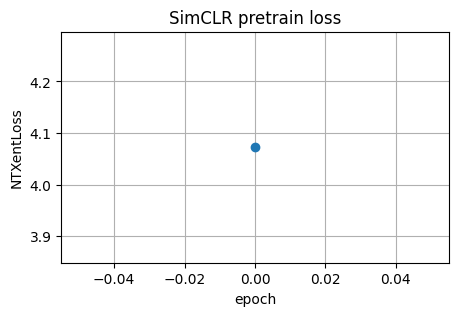

In [ ]:
model.train()
loss_history = []
t0 = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    running = 0.0
    pbar = tqdm(train_loader, desc=f"pretrain epoch {epoch}/{PRETRAIN_EPOCHS}")
    for (x0, x1), _ in pbar:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=USE_AMP):
            z0 = model(x0)
            z1 = model(x1)
            loss = criterion(z0, z1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += float(loss.detach().cpu())
        pbar.set_postfix(loss=float(loss.detach().cpu()))

    avg_loss = running / max(1, len(train_loader))
    loss_history.append(avg_loss)
    print(f"epoch {epoch}: loss={avg_loss:.4f}")

print(f"pretrain done in {(time.time() - t0):.1f}s")
plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker="o")
plt.title("SimCLR pretrain loss")
plt.xlabel("epoch")
plt.ylabel("NTXentLoss")
plt.grid(True)
plt.show()


In [ ]:
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

backbone_path = OUT_DIR / "backbone_only.pt"
torch.save(model.backbone.state_dict(), backbone_path)
print("saved:", backbone_path)


saved: /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/output/backbone_only.pt


## 3) Downstream: поиск похожих изображений (retrieval)

Теперь используем только **backbone** (без projection head), получаем эмбеддинги изображений и находим nearest neighbors по cosine similarity.

Почему это downstream задача:
- мы **не оптимизируем** сеть под retrieval-лосс (в этой тетрадке),
- мы просто применяем предобученные признаки к прикладной задаче.


In [18]:
# Используем предобученный backbone для эмбеддингов
embedder = nn.Sequential(model.backbone, nn.Flatten(start_dim=1)).to(device)
embedder.eval()

# Для retrieval используем обычный детерминированный preprocessing
val_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

class SingleViewDataset(Dataset):
    def __init__(self, paths: list[Path], transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        with Image.open(path) as img:
            img = img.convert("RGB")
        return self.transform(img), str(path)


val_ds = SingleViewDataset(val_paths, transform=val_transform)
val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

embs = []
paths = []
with torch.inference_mode():
    for x, p in tqdm(val_loader, desc="embedding"):
        x = x.to(device, non_blocking=True)
        e = embedder(x)
        e = torch.nn.functional.normalize(e, dim=1)
        embs.append(e.cpu())
        paths.extend(list(p))

embs = torch.cat(embs, dim=0)
print("embeddings shape:", tuple(embs.shape))


embedding: 100%|██████████| 2/2 [00:00<00:00,  3.07it/s]

embeddings shape: (100, 512)


In [ ]:
sims = embs @ embs.T
n = sims.shape[0]

TOPK = min(6, n)
NUM_QUERIES = min(5, n)

gen = torch.Generator().manual_seed(SEED)
query_indices = torch.randperm(n, generator=gen)[:NUM_QUERIES].tolist()

rows = []
for qi in query_indices:
    vals, idxs = torch.topk(sims[qi], k=TOPK, largest=True)
    rows.append((qi, idxs.tolist(), vals.tolist()))

print("example query:", query_indices[0])
print("paths for topk:")
for idx in rows[0][1]:
    print("-", paths[idx])


example query: 42
paths for topk:
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/219090.jpg
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/134035.jpg
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/119082.jpg
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/296059.jpg
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/285079.jpg
- /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/dataset/images/val/78004.jpg


saved: /Users/nikitagorovenko/Documents/Projects/ThirdSemester/ImageProcessingAndRecognition/ssl_lightly/output/retrieval_grid.png


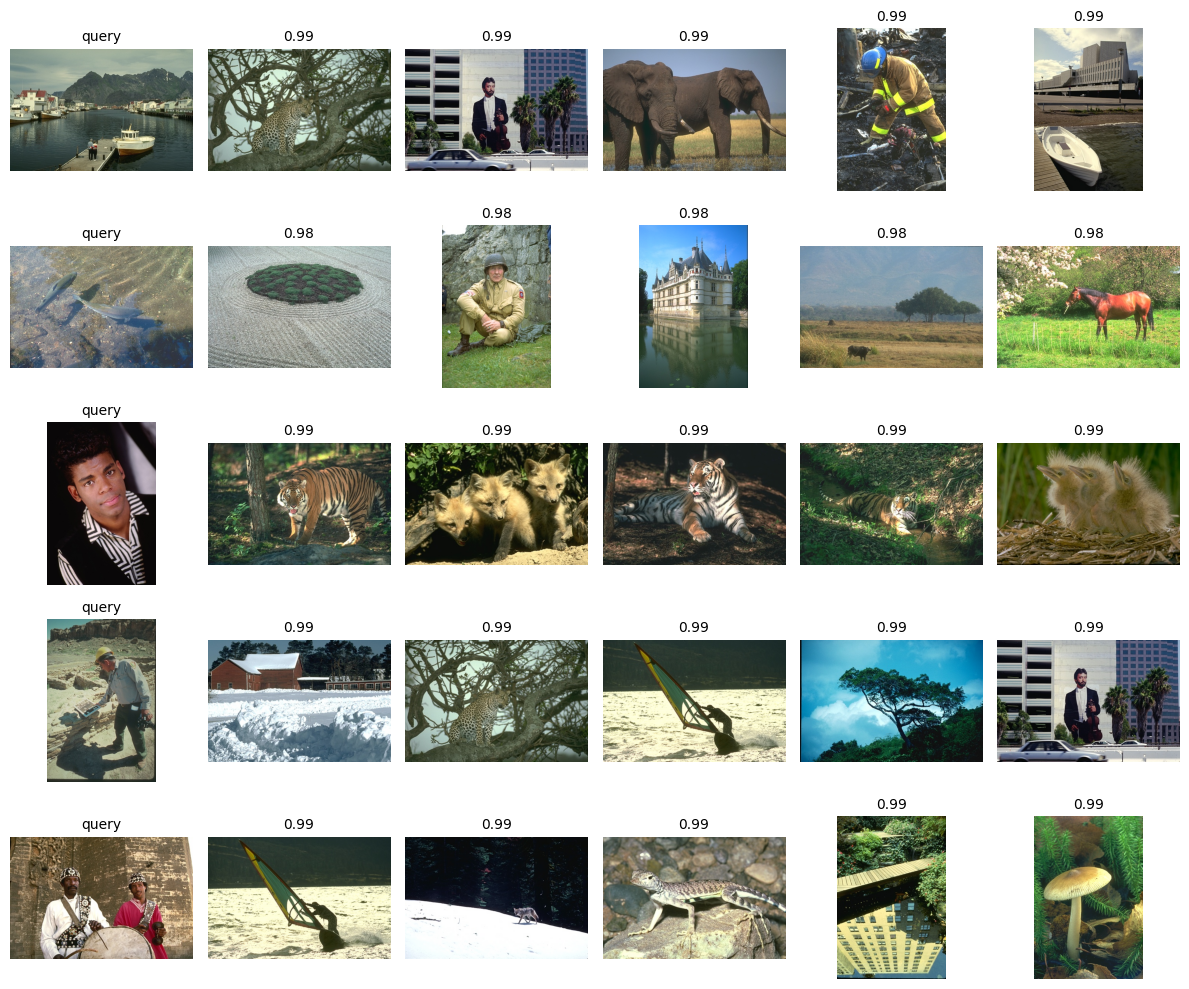

In [ ]:
fig_w = max(8, 2 * TOPK)
fig_h = max(2, 2 * len(rows))
fig, axes = plt.subplots(len(rows), TOPK, figsize=(fig_w, fig_h))
if len(rows) == 1:
    axes = [axes]

for r, (_, idxs, vals) in enumerate(rows):
    for c, (idx, sim) in enumerate(zip(idxs, vals)):
        ax = axes[r][c]
        with Image.open(paths[idx]) as img:
            ax.imshow(img.convert("RGB"))
        title = "query" if c == 0 else f"{sim:.2f}"
        ax.set_title(title, fontsize=10)
        ax.axis("off")

fig.tight_layout()
out_png = OUT_DIR / "retrieval_grid.png"
fig.savefig(out_png, dpi=160)
print("saved:", out_png)
plt.show()
